# Route B Experiment

**Flow:**
1. Load CLC data for 50 contracts
2. Fit GMM on **training period** → get soft probs `[p0, p1, p2]`
3. Apply GMM to **full period** → augment state: `9-dim + 3-dim = 12-dim`
4. Train A2C (`n_features=12`) on training period
5. Evaluate on test period
6. Compare metrics with original Route A (baseline 9-dim A2C)

**Periods:**
| Period | Train | Test |
|--------|-------|------|
| Period 1 | 2005-01-01 ~ 2010-12-31 | 2011-01-01 ~ 2015-12-31 |
| Period 2 | 2010-01-01 ~ 2015-12-31 | 2016-01-01 ~ 2019-12-31 |

## Section 0: Setup

In [2]:
import sys, os
from pathlib import Path

# Project root
PROJECT_ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'rl_models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logger = logging.getLogger(__name__)

print('✅ Setup complete')

✅ Setup complete


## Section 1: Load CLC Data

In [3]:
from data_loader import load_clc_full
from config import ASSET_CLASSES

# All tickers
all_tickers = [t for tickers in ASSET_CLASSES.values() for t in tickers]

# Load with enough history for warmup (GMM needs 60+252 rows min)
DATA_START = '2004-01-01'

clc_data = {}
for ticker in all_tickers:
    try:
        df = load_clc_full(ticker, start_date=DATA_START)
        if df is not None:
            clc_data[ticker] = df
    except Exception as e:
        pass

print(f'✅ Loaded {len(clc_data)}/{len(all_tickers)} tickers')
for ac, tickers in ASSET_CLASSES.items():
    n = sum(1 for t in tickers if t in clc_data)
    print(f'  {ac}: {n}/{len(tickers)}')

✅ Loaded 50/50 tickers
  Commodity: 25/25
  Equity Index: 11/11
  Fixed Income: 5/5
  Forex: 9/9


## Section 2: Regime Detection (Fit GMM on Training Period)

This corresponds to the **Regime Detection** block in the flowchart:  
`Load Data → Build 60×9 matrix → FFT (180-dim) → GMM (n=3) → soft probs [p0,p1,p2]`

We fit one GMM **per asset class per period** using only training data.

In [4]:
from regime_detection.timeseries_fft_regime import (
    detect_regimes_for_asset_class_timeseries,
    predict_regime_soft_probs,
)

PERIODS = {
    'period_1': {
        'train': ('2005-01-01', '2010-12-31'),
        'test' : ('2011-01-01', '2015-12-31'),
    },
    'period_2': {
        'train': ('2010-01-01', '2015-12-31'),
        'test' : ('2016-01-01', '2019-12-31'),
    },
}

# Build 'All' class
ASSET_CLASSES_WITH_ALL = dict(ASSET_CLASSES)
ASSET_CLASSES_WITH_ALL['All'] = all_tickers

print('Asset classes:', list(ASSET_CLASSES_WITH_ALL.keys()))

Asset classes: ['Commodity', 'Equity Index', 'Fixed Income', 'Forex', 'All']


In [5]:
# Fit GMM on training periods
# Stores: train_regime_results[period_name][asset_class] = result dict

train_regime_results = {}

for period_name, cfg in PERIODS.items():
    train_start, train_end = cfg['train']
    print(f'\n{"="*60}')
    print(f'  {period_name}  Training period: {train_start} ~ {train_end}')
    print(f'{"="*60}')
    
    train_regime_results[period_name] = {}
    
    for asset_class, tickers in ASSET_CLASSES_WITH_ALL.items():
        result = detect_regimes_for_asset_class_timeseries(
            clc_data=clc_data,
            asset_class_tickers=tickers,
            asset_class_name=asset_class,
            n_regimes=3,
            date_range=(train_start, train_end),
        )
        if result is not None:
            train_regime_results[period_name][asset_class] = result
            print(f'  ✅ {asset_class}: {result["n_time_points"]} time points | '
                  f'Silhouette={result["silhouette_score"]:.4f}')

print('\n✅ GMM fitting complete')

INFO 
处理 Commodity (25 个资产)...
INFO   时间范围: 2005-01-01 ~ 2010-12-31
INFO   ✓ CC: 1507 个交易日
INFO   ✓ DA: 1507 个交易日
INFO   ✓ GI: 1510 个交易日
INFO   ✓ JO: 1507 个交易日
INFO   ✓ KC: 1507 个交易日
INFO   ✓ KW: 1511 个交易日
INFO   ✓ LB: 1511 个交易日
INFO   ✓ NR: 1511 个交易日
INFO   ✓ SB: 1507 个交易日
INFO   ✓ ZA: 1512 个交易日
INFO   ✓ ZC: 1512 个交易日
INFO   ✓ ZF: 1511 个交易日
INFO   ✓ ZG: 1512 个交易日
INFO   ✓ ZH: 1510 个交易日
INFO   ✓ ZI: 1512 个交易日
INFO   ✓ ZK: 1511 个交易日
INFO   ✓ ZL: 1512 个交易日
INFO   ✓ ZO: 1510 个交易日
INFO   ✓ ZP: 1512 个交易日
INFO   ✓ ZR: 1512 个交易日
INFO   ✓ ZT: 1511 个交易日
INFO   ✓ ZU: 1508 个交易日
INFO   ✓ ZW: 1512 个交易日
INFO   ✓ ZZ: 1511 个交易日
INFO   ✓ ZN: 1509 个交易日
INFO   ✓ 加载了 25 个有效资产
INFO   时间范围: 2005-01-03 至 2010-12-31 (1507 个交易日)
INFO   生成时间序列特征...



  period_1  Training period: 2005-01-01 ~ 2010-12-31


  Commodity: 100%|██████████| 1447/1447 [02:59<00:00,  8.07it/s]
INFO   ✓ 生成 1447 个时间点的特征 ((1447, 180))
INFO   执行GMM聚类 (n_clusters=3)...
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237:

  ✅ Commodity: 1447 time points | Silhouette=0.1890


  Equity Index: 100%|██████████| 1451/1451 [01:22<00:00, 17.62it/s]
INFO   ✓ 生成 1451 个时间点的特征 ((1451, 180))
INFO   执行GMM聚类 (n_clusters=3)...
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:2

...

  ✅ Fixed Income: 1455 time points | Silhouette=0.0190


  Forex: 100%|██████████| 1448/1448 [01:03<00:00, 22.75it/s]
INFO   ✓ 生成 1448 个时间点的特征 ((1448, 180))
INFO   执行GMM聚类 (n_clusters=3)...
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Run

  ✅ Forex: 1448 time points | Silhouette=0.1018


  All: 100%|██████████| 1448/1448 [06:36<00:00,  3.65it/s]
INFO   ✓ 生成 1448 个时间点的特征 ((1448, 180))
INFO   执行GMM聚类 (n_clusters=3)...
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ladymie/Documents/GitHub/IEOR4733_Project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Runti

  ✅ All: 1448 time points | Silhouette=0.1240

✅ GMM fitting complete


## Section 3: Visualize Training-Period Regime Labels

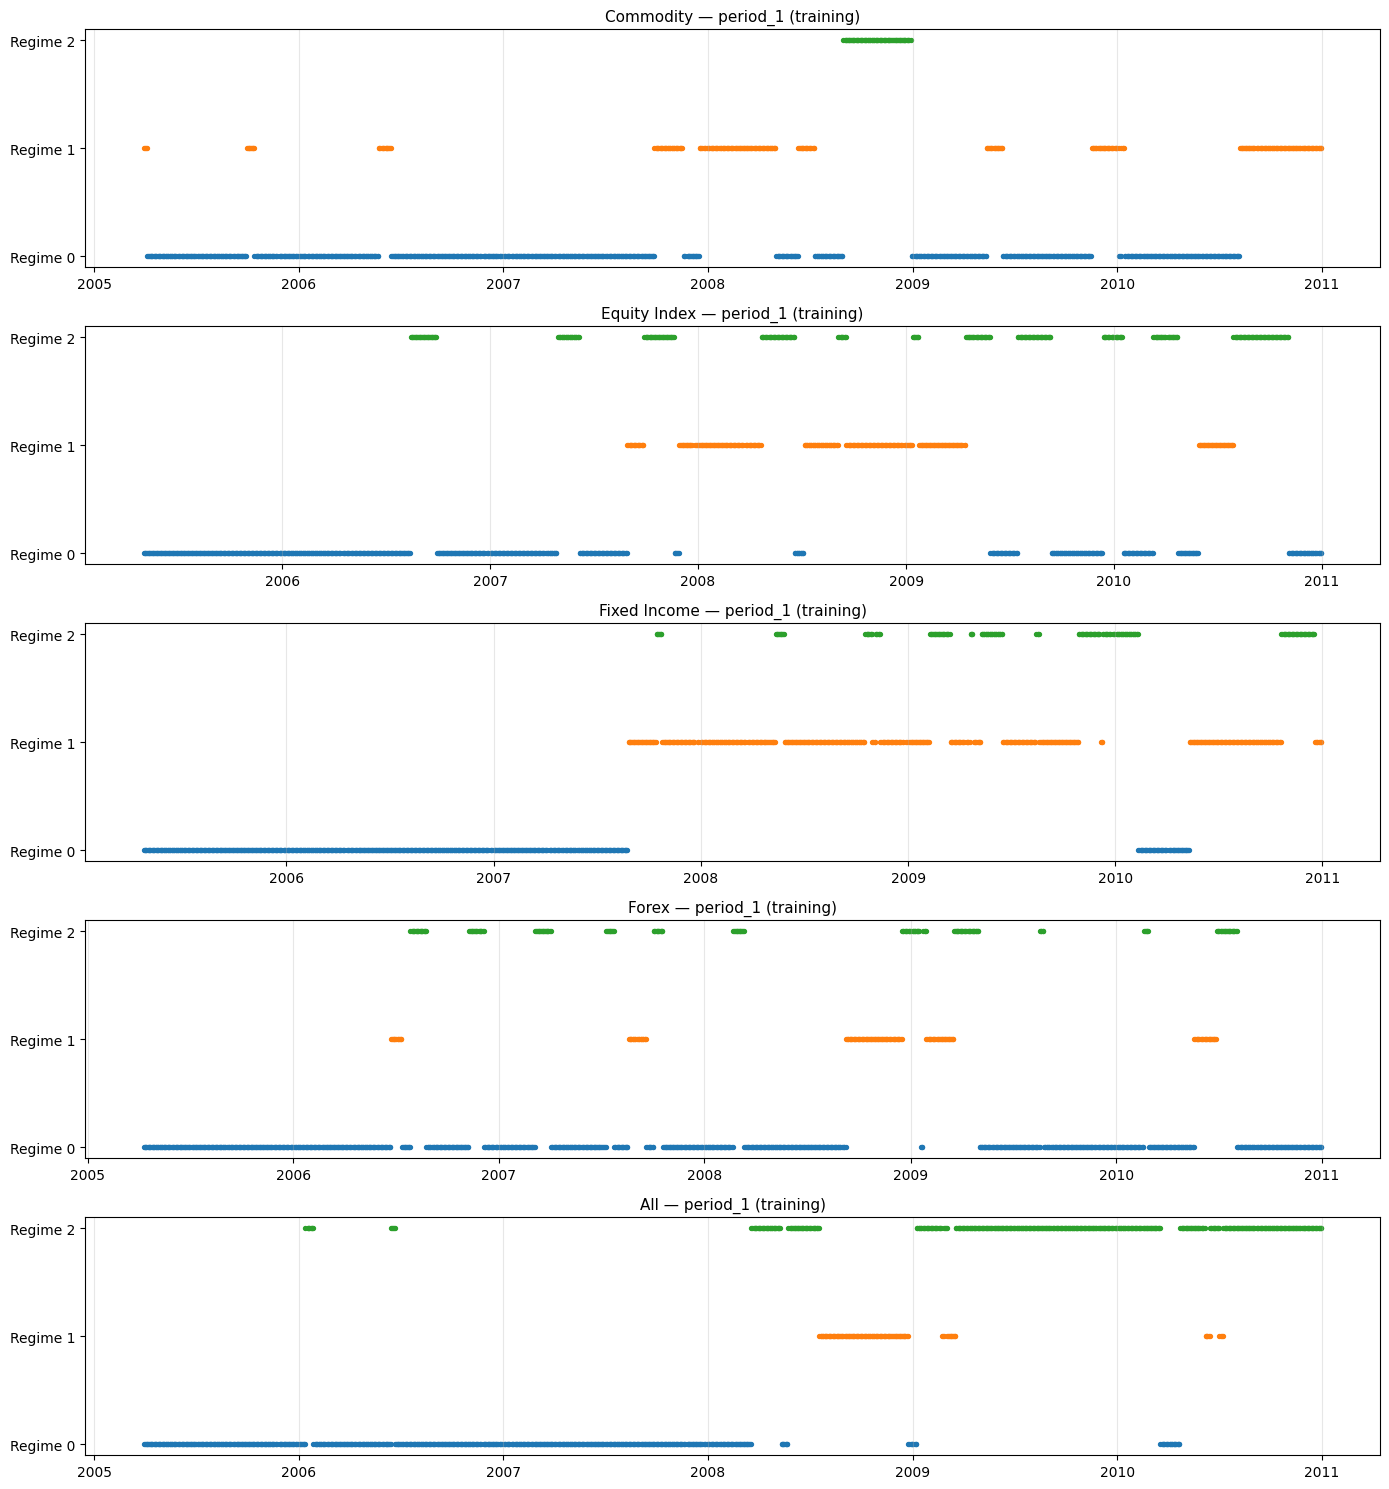

Saved regime_timeseries.png


In [6]:
# Pick period_1, plot regime timeseries for each asset class
period_to_plot = 'period_1'

n_classes = len(train_regime_results[period_to_plot])
fig, axes = plt.subplots(n_classes, 1, figsize=(14, 3 * n_classes), sharex=False)
if n_classes == 1:
    axes = [axes]

palette = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}

for ax, (asset_class, result) in zip(axes, train_regime_results[period_to_plot].items()):
    regime_df = result['regime_df']
    for r in range(3):
        mask = regime_df['regime'] == r
        ax.scatter(
            regime_df.loc[mask, 'date'],
            [r] * mask.sum(),
            c=palette[r], s=8, label=f'Regime {r}'
        )
    ax.set_title(f'{asset_class} — {period_to_plot} (training)', fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Regime 0', 'Regime 1', 'Regime 2'])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'regime_detection' / 'regime_timeseries.png', dpi=120)
plt.show()
print('Saved regime_timeseries.png')

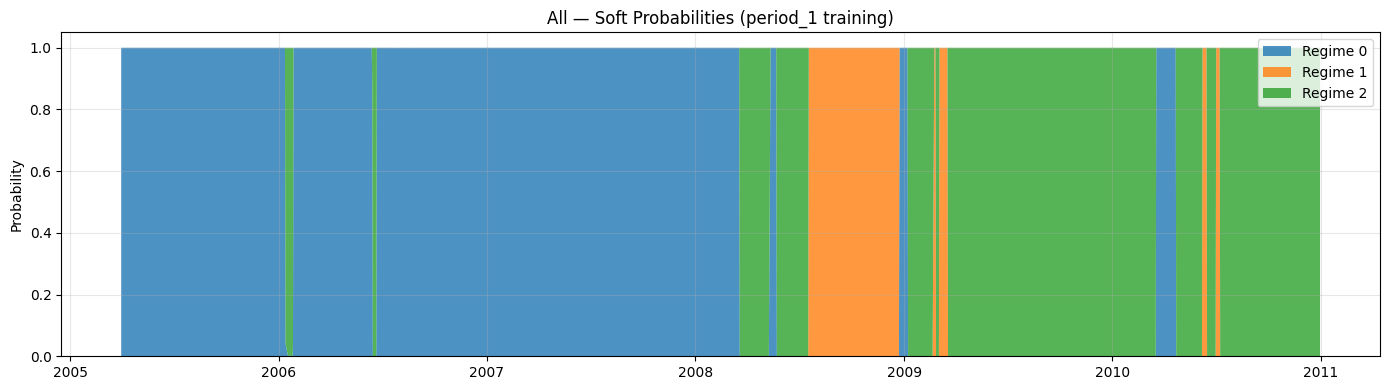

Saved regime_probabilities.png


In [7]:
# Soft probability stacked area chart
period_to_plot = 'period_1'
asset_to_plot  = 'All'   # change to 'Commodity', 'Forex', etc.

result = train_regime_results[period_to_plot].get(asset_to_plot)
if result is None:
    print(f'{asset_to_plot} not available')
else:
    regime_df = result['regime_df'].copy()
    regime_df = regime_df.sort_values('date')

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.stackplot(
        regime_df['date'],
        regime_df['regime_prob_0'],
        regime_df['regime_prob_1'],
        regime_df['regime_prob_2'],
        labels=['Regime 0', 'Regime 1', 'Regime 2'],
        colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
        alpha=0.8
    )
    ax.set_title(f'{asset_to_plot} — Soft Probabilities ({period_to_plot} training)', fontsize=12)
    ax.set_ylabel('Probability')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'regime_detection' / 'regime_probabilities.png', dpi=120)
    plt.show()
    print('Saved regime_probabilities.png')

## Section 4: Predict Soft Probs for Full Period (Train + Test)

Apply the trained GMM to the combined train+test window to get soft probs  
for every trading day, so we can augment the A2C state during both training and test.

In [8]:
# full_regime_dfs[period_name][asset_class] = DataFrame(date, regime, p0, p1, p2)
full_regime_dfs = {}

FULL_RANGES = {
    'period_1': (DATA_START, '2015-12-31'),
    'period_2': (DATA_START, '2019-12-31'),
}

for period_name, cfg in PERIODS.items():
    full_start, full_end = FULL_RANGES[period_name]
    print(f'\n{period_name} full range: {full_start} ~ {full_end}')
    
    full_regime_dfs[period_name] = {}
    
    for asset_class, tickers in ASSET_CLASSES_WITH_ALL.items():
        if asset_class not in train_regime_results[period_name]:
            continue
        
        trained_result = train_regime_results[period_name][asset_class]
        
        regime_df = predict_regime_soft_probs(
            clc_data=clc_data,
            asset_class_tickers=tickers,
            asset_class_name=asset_class,
            trained_gmm=trained_result['gmm_model'],
            trained_scaler=trained_result['fft_scaler'],
            date_range=(full_start, full_end),
        )
        
        if regime_df is not None:
            full_regime_dfs[period_name][asset_class] = regime_df
            print(f'  ✅ {asset_class}: {len(regime_df)} time points')
        else:
            print(f'  ❌ {asset_class}: failed')

print('\n✅ Full-period soft probs ready')

INFO 
[predict] Commodity soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31



period_1 full range: 2004-01-01 ~ 2015-12-31


INFO   time range: 2004-01-06 ~ 2015-12-31 (3014 days)
  Commodity (predict): 100%|██████████| 2954/2954 [06:56<00:00,  7.09it/s]
INFO   ✓ Commodity: 2954 time points predicted
INFO 
[predict] Equity Index soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31
INFO   time range: 2004-03-08 ~ 2015-12-31 (3024 days)


  ✅ Commodity: 2954 time points


  Equity Index (predict): 100%|██████████| 2964/2964 [03:09<00:00, 15.63it/s]
INFO   ✓ Equity Index: 2964 time points predicted
INFO 
[predict] Fixed Income soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31
INFO   time range: 2004-02-16 ~ 2015-12-30 (3022 days)


...

  ✅ Fixed Income: 3968 time points


  Forex (predict): 100%|██████████| 3961/3961 [05:42<00:00, 11.55it/s] 
INFO   ✓ Forex: 3961 time points predicted
INFO 
[predict] All soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2019-12-31
INFO   time range: 2004-01-08 ~ 2019-12-31 (4019 days)


  ✅ Forex: 3961 time points


  All (predict): 100%|██████████| 3959/3959 [46:20<00:00,  1.42it/s]    
INFO   ✓ All: 3959 time points predicted


  ✅ All: 3959 time points

✅ Full-period soft probs ready


## Section 5: Build 12-dim Augmented State & Train A2C

State = `[close_norm, ret_1m, ret_2m, ret_3m, ret_1y, macd_8_24, macd_16_48, macd_32_96, rsi_30]`  
+ `[regime_prob_0, regime_prob_1, regime_prob_2]`  
= **12-dim** input per time step in the 60-step LSTM window.

In [9]:
from regime_detection.route_b_train import (
    run_route_b,
    _load_rad_data_for_a2c,
    _build_augmented_state_dict,
    FEATURE_COLS_12,
    SIGMA_TARGET,
)
from rl_models.a2c_model import PaperA2CTrainer, build_envs_from_state_dict, DEVICE

print('FEATURE_COLS_12:', FEATURE_COLS_12)
print('SIGMA_TARGET (daily):', f'{SIGMA_TARGET:.6f}  (~{SIGMA_TARGET*np.sqrt(252)*100:.1f}% annual)')
print('Device:', DEVICE)

FEATURE_COLS_12: ['close_norm', 'ret_1m', 'ret_2m', 'ret_3m', 'ret_1y', 'macd_8_24', 'macd_16_48', 'macd_32_96', 'rsi_30', 'regime_prob_0', 'regime_prob_1', 'regime_prob_2']
SIGMA_TARGET (daily): 0.009449  (~15.0% annual)
Device: cpu


In [18]:
# ── Choose what to train ──────────────────────────────────────────────────────
# Set QUICK_TEST=True for a fast sanity check (100 updates, single asset class)
# Set QUICK_TEST=False to run all classes and both periods

QUICK_TEST    = False
N_UPDATES     = 100   if QUICK_TEST else 2000
TARGET_CLASSES = ['All'] if QUICK_TEST else list(ASSET_CLASSES_WITH_ALL.keys())
TARGET_PERIODS = ['period_1'] if QUICK_TEST else ['period_1', 'period_2']

print(f'QUICK_TEST={QUICK_TEST}  N_UPDATES={N_UPDATES}')
print(f'Classes: {TARGET_CLASSES}')
print(f'Periods: {TARGET_PERIODS}')

QUICK_TEST=False  N_UPDATES=2000
Classes: ['Commodity', 'Equity Index', 'Fixed Income', 'Forex', 'All']
Periods: ['period_1', 'period_2']


In [19]:
# Train Route B models
# Results stored in route_b_results[period_name][asset_class]

route_b_results = {}

for period_name in TARGET_PERIODS:
    route_b_results[period_name] = {}
    cfg = PERIODS[period_name]
    train_start, train_end = cfg['train']
    test_start,  test_end  = cfg['test']

    for asset_class in TARGET_CLASSES:
        tickers = ASSET_CLASSES_WITH_ALL[asset_class]

        if asset_class not in full_regime_dfs.get(period_name, {}):
            print(f'⚠️  No regime data for {asset_class} {period_name}, skipping')
            continue

        print(f'\n{"="*60}')
        print(f'Training Route B: {asset_class} | {period_name}')
        print(f'{"="*60}')

        # Load RAD features (9-dim)
        feature_dict = _load_rad_data_for_a2c(tickers, DATA_START, test_end)

        # Build 12-dim augmented state
        regime_df = full_regime_dfs[period_name][asset_class]
        train_sd, test_sd = _build_augmented_state_dict(
            feature_dict=feature_dict,
            regime_df=regime_df,
            train_start=train_start, train_end=train_end,
            test_start=test_start,   test_end=test_end,
        )

        print(f'  Train tickers: {len(train_sd)}  |  Test tickers: {len(test_sd)}')
        if not train_sd:
            print('  ❌ No training states')
            continue

        # Build envs and train
        train_envs = build_envs_from_state_dict(
            state_dict=train_sd,
            tickers=list(train_sd.keys()),
            sigma_target=SIGMA_TARGET,
        )
        print(f'  Training envs: {len(train_envs)}')

        ckpt_path = str(
            PROJECT_ROOT / 'rl_models' /
            f'a2c_rb_{asset_class.replace(" ", "_")}_{period_name}.pt'
        )

        trainer = PaperA2CTrainer(n_features=12, device=DEVICE)
        trainer.fit(
            envs=train_envs,
            n_updates=N_UPDATES,
            rollout_steps=32,
            log_every=max(1, N_UPDATES // 10),
            checkpoint_path=ckpt_path,
            checkpoint_every=max(1, N_UPDATES // 5),
        )
        trainer.save_checkpoint(ckpt_path)
        print(f'  ✅ Checkpoint saved: {Path(ckpt_path).name}')

        route_b_results[period_name][asset_class] = {
            'trainer': trainer,
            'test_sd': test_sd,
            'checkpoint': ckpt_path,
        }

print('\n✅ Training complete')


Training Route B: Commodity | period_1
  Train tickers: 22  |  Test tickers: 23
  Training envs: 22
[ 200] actor_loss=0.0300 critic_loss=0.0000 avg_reward=-0.000427 entropy=0.9079
[ 400] actor_loss=-0.0100 critic_loss=0.0000 avg_reward=-0.000392 entropy=0.8935
checkpoint saved to /Users/ladymie/Documents/GitHub/IEOR4733_Project/rl_models/a2c_rb_Commodity_period_1.pt
[ 600] actor_loss=-0.0937 critic_loss=0.0000 avg_reward=-0.000451 entropy=0.8814
[ 800] actor_loss=0.0144 critic_loss=0.0001 avg_reward=-0.000793 entropy=0.8723
checkpoint saved to /Users/ladymie/Documents/GitHub/IEOR4733_Project/rl_models/a2c_rb_Commodity_period_1.pt
[1000] actor_loss=0.0397 critic_loss=0.0000 avg_reward=-0.000962 entropy=0.8621
[1200] actor_loss=-0.0363 critic_loss=0.0001 avg_reward=-0.000071 entropy=0.8538
checkpoint saved to /Users/ladymie/Documents/GitHub/IEOR4733_Project/rl_models/a2c_rb_Commodity_period_1.pt
[1400] actor_loss=-0.0347 critic_loss=0.0001 avg_reward=-0.000203 entropy=0.8457
[1600] acto

KeyboardInterrupt: 

## Section 6: Evaluate on Test Period

In [20]:
from regime_detection.route_b_train import _evaluate

eval_results = {}

for period_name, ac_dict in route_b_results.items():
    eval_results[period_name] = {}
    for asset_class, obj in ac_dict.items():
        metrics = _evaluate(
            actor=obj['trainer'].actor,
            test_state_dict=obj['test_sd'],
            sigma_target=SIGMA_TARGET,
        )
        eval_results[period_name][asset_class] = metrics
        print(
            f'{period_name} | {asset_class:<16} '
            f'Sharpe={metrics.get("portfolio_sharpe", float("nan")):.3f}  '
            f'Calmar={metrics.get("portfolio_calmar", float("nan")):.3f}  '
            f'AnnRet={metrics.get("portfolio_ann_ret", float("nan")):.4f}'
        )

KeyboardInterrupt: 

## Section 7: Compare Route A (Baseline) vs Route B

In [13]:
# Load original A2C checkpoints (Route A, 9-dim)
from rl_models.a2c_model import load_actor_from_checkpoint

# Route A actors already trained
route_a_actors = {}
for period_num in [1, 2]:
    for asset_class in TARGET_CLASSES:
        ac_label = asset_class.replace(' ', '_')
        ckpt = PROJECT_ROOT / 'rl_models' / f'a2c_{ac_label}_period{period_num}.pt'
        if ckpt.exists():
            actor = load_actor_from_checkpoint(str(ckpt), n_features=9, device=DEVICE)
            route_a_actors[f'{asset_class}_period_{period_num}'] = actor
            print(f'  Loaded Route A: {ckpt.name}')
        else:
            print(f'  ⚠️  Not found: {ckpt.name}')

  Loaded Route A: a2c_All_period1.pt
  Loaded Route A: a2c_All_period2.pt


In [14]:
# Build 9-dim test states for Route A comparison
from rl_models.loaddata import make_state_tensor_single
from regime_detection.route_b_train import FEATURE_COLS_9

route_a_eval_results = {}

for period_name in TARGET_PERIODS:
    cfg = PERIODS[period_name]
    train_start, train_end = cfg['train']
    test_start,  test_end  = cfg['test']
    period_num = period_name.split('_')[1]  # '1' or '2'

    route_a_eval_results[period_name] = {}

    for asset_class in TARGET_CLASSES:
        key = f'{asset_class}_period_{period_num}'
        if key not in route_a_actors:
            continue

        tickers = ASSET_CLASSES_WITH_ALL[asset_class]
        feature_dict = _load_rad_data_for_a2c(tickers, DATA_START, test_end)

        test_s = pd.Timestamp(test_start)
        test_e = pd.Timestamp(test_end)

        test_sd_9 = {}
        for ticker, feat_df in feature_dict.items():
            try:
                te_df = feat_df[
                    (feat_df['date'] >= test_s) & (feat_df['date'] <= test_e)
                ].reset_index(drop=True)

                X_te, _, al_te = make_state_tensor_single(
                    te_df, FEATURE_COLS_9, window=60,
                    return_dates=True, return_current_row=True,
                )
                if len(X_te) > 0:
                    test_sd_9[ticker] = {
                        'X': X_te,
                        'aligned_df': al_te[['date', 'close', 'ret_1d', 'ewm_vol_60']],
                    }
            except Exception:
                pass

        metrics_a = _evaluate(
            actor=route_a_actors[key],
            test_state_dict=test_sd_9,
            sigma_target=SIGMA_TARGET,
        )
        route_a_eval_results[period_name][asset_class] = metrics_a
        print(
            f'Route A | {period_name} | {asset_class:<16} '
            f'Sharpe={metrics_a.get("portfolio_sharpe", float("nan")):.3f}  '
            f'Calmar={metrics_a.get("portfolio_calmar", float("nan")):.3f}'
        )

Route A | period_1 | All              Sharpe=-0.397  Calmar=-0.095


In [15]:
# Summary comparison table
rows = []
metrics_to_show = ['portfolio_sharpe', 'portfolio_calmar', 'portfolio_ann_ret', 'portfolio_ann_std', 'portfolio_mdd']
col_labels      = ['Sharpe', 'Calmar', 'Ann.Ret', 'Ann.Std', 'MDD']

for period_name in TARGET_PERIODS:
    for asset_class in TARGET_CLASSES:
        ra = route_a_eval_results.get(period_name, {}).get(asset_class, {})
        rb = eval_results.get(period_name, {}).get(asset_class, {})

        for route_label, m in [('Route A (9-dim)', ra), ('Route B (12-dim)', rb)]:
            row = {'Period': period_name, 'Asset Class': asset_class, 'Model': route_label}
            for col, key in zip(col_labels, metrics_to_show):
                row[col] = round(m.get(key, float('nan')), 4)
            rows.append(row)

if rows:
    comparison_df = pd.DataFrame(rows)
    display(comparison_df.set_index(['Period', 'Asset Class', 'Model']))
else:
    print('No results to compare yet')

Sharpe  Calmar  Ann.Ret  Ann.Std  \
Period   Asset Class Model                                                
period_1 All         Route A (9-dim)  -0.3969 -0.0945  -0.0011   0.0029   
                     Route B (12-dim) -0.2944 -0.0726  -0.0026   0.0088   

                                          MDD  
Period   Asset Class Model                     
period_1 All         Route A (9-dim)  -0.0120  
                     Route B (12-dim) -0.0358

## Section 8: Training Loss Curve

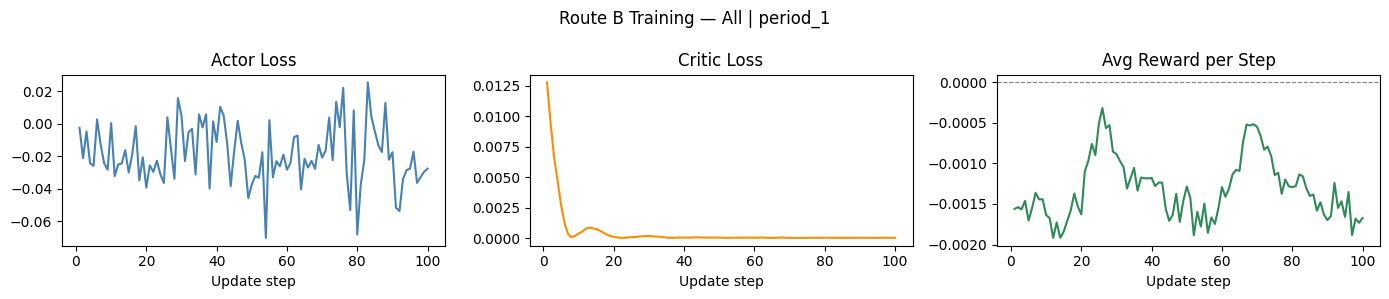

In [16]:
# Plot actor/critic loss for Route B training
for period_name, ac_dict in route_b_results.items():
    for asset_class, obj in ac_dict.items():
        log = obj['trainer'].train_log
        if not log:
            continue

        steps        = list(range(1, len(log) + 1))
        actor_losses = [x['actor_loss'] for x in log]
        critic_losses= [x['critic_loss'] for x in log]
        avg_rewards  = [x['avg_reward'] for x in log]

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))
        axes[0].plot(steps, actor_losses,  color='steelblue')
        axes[0].set_title('Actor Loss')
        axes[0].set_xlabel('Update step')

        axes[1].plot(steps, critic_losses, color='darkorange')
        axes[1].set_title('Critic Loss')
        axes[1].set_xlabel('Update step')

        axes[2].plot(steps, avg_rewards,   color='seagreen')
        axes[2].set_title('Avg Reward per Step')
        axes[2].set_xlabel('Update step')
        axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')

        fig.suptitle(f'Route B Training — {asset_class} | {period_name}', fontsize=12)
        plt.tight_layout()
        plt.show()

## Section 9: Save Full-Period Regime CSVs for Reuse

In [17]:
# Save the full-period soft prob CSVs to regime_detection/results/
results_dir = PROJECT_ROOT / 'regime_detection' / 'results'
results_dir.mkdir(exist_ok=True)

for period_name, ac_dict in full_regime_dfs.items():
    for asset_class, regime_df in ac_dict.items():
        fname = f'regime_routeB_{period_name}_{asset_class.replace(" ", "_")}.csv'
        fpath = results_dir / fname
        regime_df.to_csv(fpath, index=False)
        print(f'  Saved {fname}  ({len(regime_df)} rows)')

print(f'\n✅ All CSVs saved to {results_dir}')

  Saved regime_routeB_period_1_Commodity.csv  (2954 rows)
  Saved regime_routeB_period_1_Equity_Index.csv  (2964 rows)
  Saved regime_routeB_period_1_Fixed_Income.csv  (2962 rows)
  Saved regime_routeB_period_1_Forex.csv  (2954 rows)
  Saved regime_routeB_period_1_All.csv  (2954 rows)
  Saved regime_routeB_period_2_Commodity.csv  (3959 rows)
  Saved regime_routeB_period_2_Equity_Index.csv  (3962 rows)
  Saved regime_routeB_period_2_Fixed_Income.csv  (3968 rows)
  Saved regime_routeB_period_2_Forex.csv  (3961 rows)
  Saved regime_routeB_period_2_All.csv  (3959 rows)

✅ All CSVs saved to /Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results
